JOB SENTINEL - EDA

Dataset loaded successfully!
Shape: (17632, 17)

Columns:
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

BASIC DATA INFORMATION

Data types:
title                    str
location                 str
department               str
salary_range             str
company_profile          str
description              str
requirements             str
benefits                 str
telecommuting            str
has_company_logo         str
has_questions            str
employment_type          str
required_experience      str
required_education       str
industry                 str
function                 str
fraudulent             int64
dtype: object

Missing values:
salary_range           14802
department             11351
required_education      8024
bene

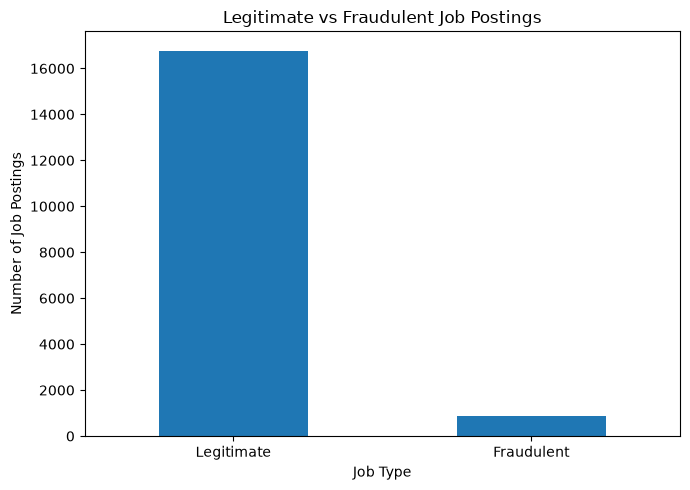


Missing-value indicators created.
New shape: (17632, 27)

COMPANY PROFILE ANALYSIS
           Legitimate %  Fraudulent %
Missing       82.343988     17.656012
Available     98.076253      1.923747


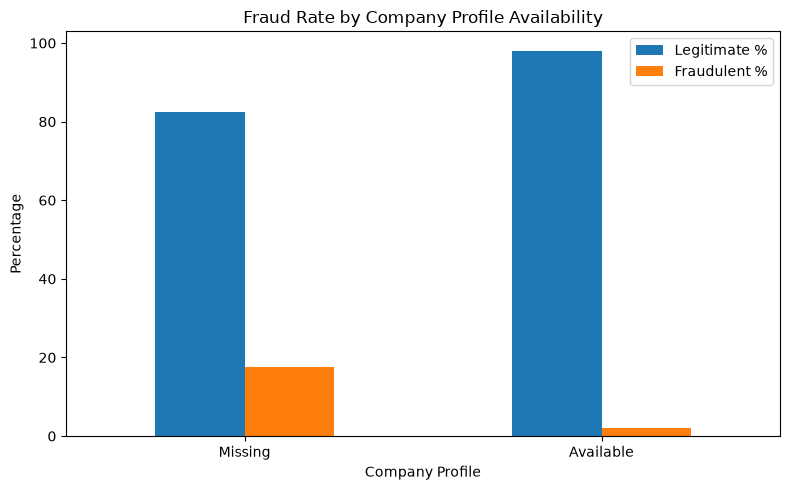


SALARY ANALYSIS
           Legitimate %  Fraudulent %
Missing       95.710039      4.289961
Available     92.190813      7.809187


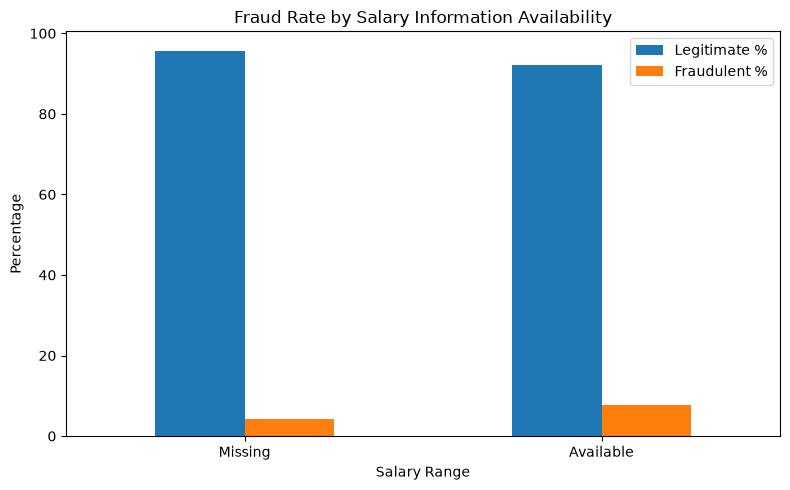


EMPLOYMENT TYPE ANALYSIS
                 Legitimate %  Fraudulent %
employment_type                            
Part-time           90.556274      9.443726
Unknown             93.125546      6.874454
Other               93.333333      6.666667
Full-time           95.746725      4.253275
Contract            97.159841      2.840159
Temporary           99.156118      0.843882


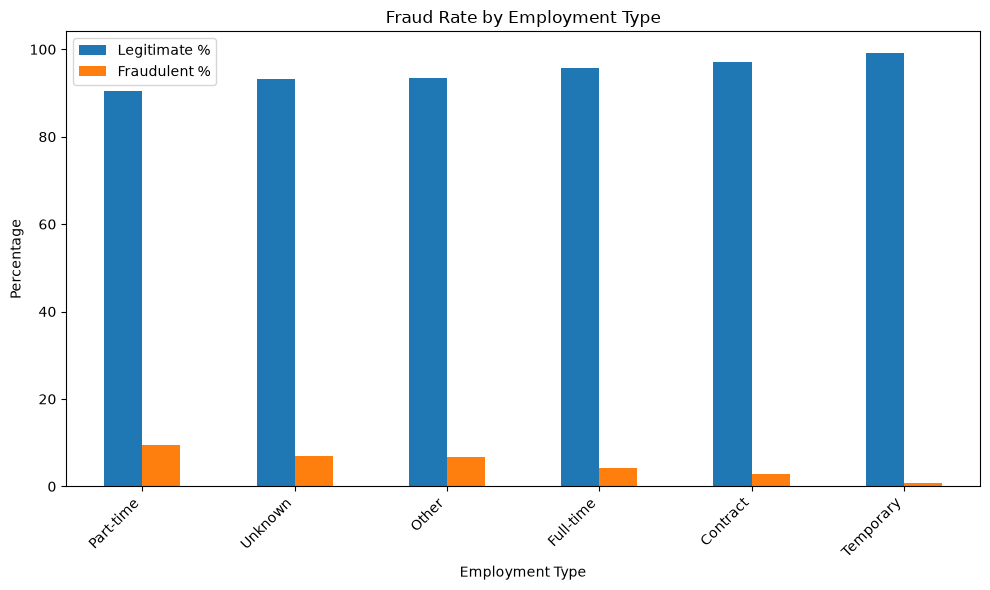


REQUIRED EXPERIENCE ANALYSIS
                     Legitimate %  Fraudulent %
required_experience                            
Executive               92.857143      7.142857
Entry level             93.303065      6.696935
Unknown                 93.875502      6.124498
Not Applicable          94.397759      5.602241
Director                95.584416      4.415584
Mid-Senior level        97.005829      2.994171
Internship              97.319035      2.680965
Associate               98.153034      1.846966


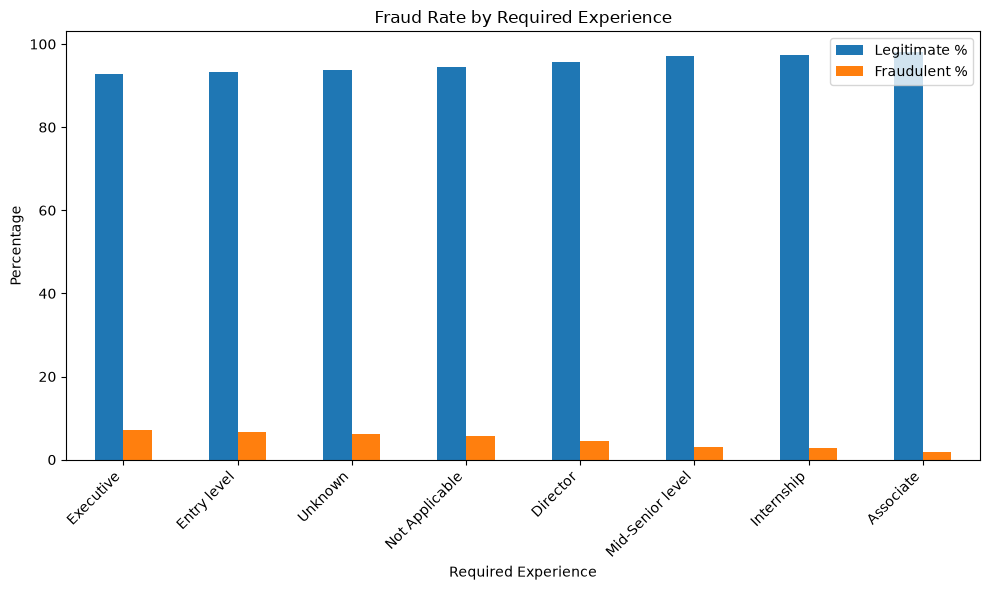


Text-length features created.

Description length:
              count         mean          std   min    25%     50%     75%  \
fraudulent                                                                   
0           16776.0  1439.570279  1709.648035  42.0  687.0  1166.0  1780.0   
1             856.0  1441.056075  1978.766938  10.0  541.0   975.5  1774.0   

                max  
fraudulent           
0           55130.0  
1           29424.0  

Requirements length:
              count        mean          std  min    25%    50%     75%  \
fraudulent                                                                
0           16776.0  744.353660  1283.227855  0.0  192.0  575.0  981.00   
1             856.0  514.441589   645.190972  0.0   62.0  294.0  739.25   

                max  
fraudulent           
0           37994.0  
1            4734.0  

Company profile length:
              count        mean         std  min    25%    50%    75%     max
fraudulent                       

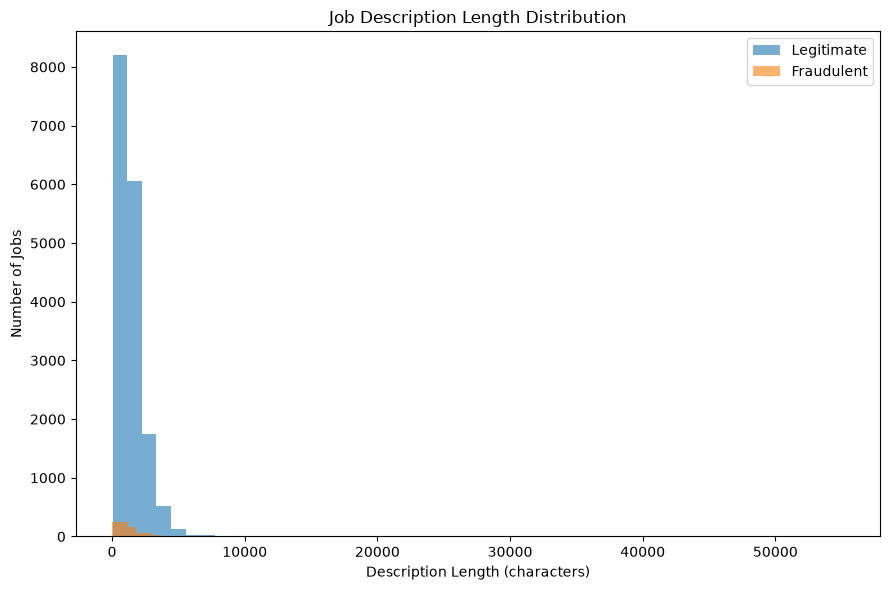


Word-count features created.

Description word count:
              count        mean         std  min    25%    50%    75%     max
fraudulent                                                                   
0           16776.0  186.926144  164.248319  8.0  94.00  157.0  240.0  3917.0
1             856.0  168.120327  147.625829  1.0  73.75  123.0  218.0  1399.0

URL-count features created.

Description URL statistics:
              count      mean       std  min  25%  50%  75%  max
fraudulent                                                      
0           16776.0  0.014187  0.173097  0.0  0.0  0.0  0.0  6.0
1             856.0  0.009346  0.096277  0.0  0.0  0.0  0.0  1.0

Email-count features created.
              count  mean  std  min  25%  50%  75%  max
fraudulent                                             
0           16776.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0
1             856.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0

Phone-number features created.
              count      mea

In [1]:
# ============================================================
# JobSentinel - Exploratory Data Analysis
# ============================================================

# ------------------------------------------------------------
# 1. IMPORTS
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from collections import Counter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


# ------------------------------------------------------------
# 2. LOAD CLEANED DATA
# ------------------------------------------------------------

DATA_PATH = "../data/processed/jobs_cleaned.csv"

df_clean = pd.read_csv(DATA_PATH)

print("=" * 60)
print("JOB SENTINEL - EDA")
print("=" * 60)

print("\nDataset loaded successfully!")
print("Shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())


# ------------------------------------------------------------
# 3. BASIC DATA INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BASIC DATA INFORMATION")
print("=" * 60)

print("\nData types:")
print(df_clean.dtypes)

print("\nMissing values:")
print(df_clean.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())


# ------------------------------------------------------------
# 4. TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

target_counts = df_clean["fraudulent"].value_counts()

print("\nCounts:")
print(target_counts)

target_percentages = (
    df_clean["fraudulent"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPercentages:")
print(target_percentages)


# ------------------------------------------------------------
# 5. TARGET VISUALIZATION
# ------------------------------------------------------------

target_plot = target_counts.copy()

target_plot.index = [
    "Legitimate" if x == 0 else "Fraudulent"
    for x in target_plot.index
]

plt.figure(figsize=(7, 5))

target_plot.plot(kind="bar")

plt.title("Legitimate vs Fraudulent Job Postings")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. MISSING VALUE INDICATORS
# ------------------------------------------------------------

missing_indicator_columns = [
    "company_profile",
    "salary_range",
    "requirements",
    "benefits",
    "department",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "employment_type",
]

for column in missing_indicator_columns:
    df_clean[f"has_{column}"] = (
        df_clean[column].notna().astype(int)
    )

print("\nMissing-value indicators created.")

print("New shape:", df_clean.shape)


# ------------------------------------------------------------
# 7. COMPANY PROFILE ANALYSIS
# ------------------------------------------------------------

company_profile_analysis = pd.crosstab(
    df_clean["has_company_profile"],
    df_clean["fraudulent"],
    normalize="index"
) * 100

company_profile_analysis.columns = [
    "Legitimate %",
    "Fraudulent %"
]

company_profile_analysis.index = [
    "Missing",
    "Available"
]

print("\n" + "=" * 60)
print("COMPANY PROFILE ANALYSIS")
print("=" * 60)

print(company_profile_analysis)


company_profile_analysis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Fraud Rate by Company Profile Availability")
plt.xlabel("Company Profile")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. SALARY ANALYSIS
# ------------------------------------------------------------

salary_analysis = pd.crosstab(
    df_clean["has_salary_range"],
    df_clean["fraudulent"],
    normalize="index"
) * 100

salary_analysis.columns = [
    "Legitimate %",
    "Fraudulent %"
]

salary_analysis.index = [
    "Missing",
    "Available"
]

print("\n" + "=" * 60)
print("SALARY ANALYSIS")
print("=" * 60)

print(salary_analysis)


salary_analysis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Fraud Rate by Salary Information Availability")
plt.xlabel("Salary Range")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. EMPLOYMENT TYPE ANALYSIS
# ------------------------------------------------------------

employment_analysis = pd.crosstab(
    df_clean["employment_type"].fillna("Unknown"),
    df_clean["fraudulent"],
    normalize="index"
) * 100

employment_analysis = employment_analysis.sort_values(
    by=1,
    ascending=False
)

employment_analysis.columns = [
    "Legitimate %",
    "Fraudulent %"
]

print("\n" + "=" * 60)
print("EMPLOYMENT TYPE ANALYSIS")
print("=" * 60)

print(employment_analysis)


employment_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Fraud Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. REQUIRED EXPERIENCE ANALYSIS
# ------------------------------------------------------------

experience_analysis = pd.crosstab(
    df_clean["required_experience"].fillna("Unknown"),
    df_clean["fraudulent"],
    normalize="index"
) * 100

experience_analysis = experience_analysis.sort_values(
    by=1,
    ascending=False
)

experience_analysis.columns = [
    "Legitimate %",
    "Fraudulent %"
]

print("\n" + "=" * 60)
print("REQUIRED EXPERIENCE ANALYSIS")
print("=" * 60)

print(experience_analysis)


experience_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Fraud Rate by Required Experience")
plt.xlabel("Required Experience")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. TEXT LENGTH FEATURES
# ------------------------------------------------------------

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in text_columns:

    df_clean[f"{column}_length"] = (
        df_clean[column]
        .fillna("")
        .astype(str)
        .str.len()
    )

print("\nText-length features created.")


print("\nDescription length:")
print(
    df_clean.groupby("fraudulent")[
        "description_length"
    ].describe()
)


print("\nRequirements length:")
print(
    df_clean.groupby("fraudulent")[
        "requirements_length"
    ].describe()
)


print("\nCompany profile length:")
print(
    df_clean.groupby("fraudulent")[
        "company_profile_length"
    ].describe()
)


# ------------------------------------------------------------
# 12. DESCRIPTION LENGTH VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.hist(
    df_clean[
        df_clean["fraudulent"] == 0
    ]["description_length"],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df_clean[
        df_clean["fraudulent"] == 1
    ]["description_length"],
    bins=50,
    alpha=0.6,
    label="Fraudulent"
)

plt.title("Job Description Length Distribution")
plt.xlabel("Description Length (characters)")
plt.ylabel("Number of Jobs")

plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. WORD COUNT FEATURES
# ------------------------------------------------------------

for column in text_columns:

    df_clean[f"{column}_word_count"] = (
        df_clean[column]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

print("\nWord-count features created.")

print("\nDescription word count:")
print(
    df_clean.groupby("fraudulent")[
        "description_word_count"
    ].describe()
)


# ------------------------------------------------------------
# 14. URL DETECTION
# ------------------------------------------------------------

def count_urls(text):

    if pd.isna(text):
        return 0

    return len(
        re.findall(
            r"https?://\S+|www\.\S+",
            str(text),
            flags=re.IGNORECASE
        )
    )


for column in text_columns:

    df_clean[f"{column}_url_count"] = (
        df_clean[column].apply(count_urls)
    )


print("\nURL-count features created.")

print(
    "\nDescription URL statistics:"
)

print(
    df_clean.groupby("fraudulent")[
        "description_url_count"
    ].describe()
)


# ------------------------------------------------------------
# 15. EMAIL DETECTION
# ------------------------------------------------------------

EMAIL_PATTERN = (
    r"\b[A-Za-z0-9._%+-]+"
    r"@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
)


def count_emails(text):

    if pd.isna(text):
        return 0

    return len(
        re.findall(
            EMAIL_PATTERN,
            str(text)
        )
    )


for column in text_columns:

    df_clean[f"{column}_email_count"] = (
        df_clean[column].apply(count_emails)
    )


print("\nEmail-count features created.")

print(
    df_clean.groupby("fraudulent")[
        "description_email_count"
    ].describe()
)


# ------------------------------------------------------------
# 16. PHONE NUMBER DETECTION
# ------------------------------------------------------------

PHONE_PATTERN = (
    r"(?<!\d)"
    r"(?:\+?\d[\d\s().-]{7,}\d)"
    r"(?!\d)"
)


def count_phone_numbers(text):

    if pd.isna(text):
        return 0

    return len(
        re.findall(
            PHONE_PATTERN,
            str(text)
        )
    )


for column in text_columns:

    df_clean[f"{column}_phone_count"] = (
        df_clean[column].apply(count_phone_numbers)
    )


print("\nPhone-number features created.")

print(
    df_clean.groupby("fraudulent")[
        "description_phone_count"
    ].describe()
)


# ------------------------------------------------------------
# 17. UPPERCASE RATIO
# ------------------------------------------------------------

def uppercase_ratio(text):

    if pd.isna(text):
        return 0.0

    text = str(text)

    letters = [
        char for char in text
        if char.isalpha()
    ]

    if not letters:
        return 0.0

    uppercase = sum(
        char.isupper()
        for char in letters
    )

    return uppercase / len(letters)


for column in text_columns:

    df_clean[f"{column}_uppercase_ratio"] = (
        df_clean[column].apply(uppercase_ratio)
    )


print("\nUppercase-ratio features created.")

print(
    df_clean.groupby("fraudulent")[
        "description_uppercase_ratio"
    ].describe()
)


# ------------------------------------------------------------
# 18. SUSPICIOUS TERM ANALYSIS
# ------------------------------------------------------------

suspicious_terms = [
    "urgent",
    "immediate",
    "work from home",
    "earn money",
    "easy money",
    "no experience",
    "quick money",
    "guaranteed",
    "investment",
    "cash",
    "wire transfer",
    "bank account",
    "western union",
    "money transfer",
    "commission",
    "telegram",
    "whatsapp",
    "bitcoin",
    "crypto"
]


def count_suspicious_terms(text):

    if pd.isna(text):
        return 0

    text = str(text).lower()

    return sum(
        text.count(term)
        for term in suspicious_terms
    )


df_clean["suspicious_term_count"] = (
    df_clean["description"]
    .apply(count_suspicious_terms)
)


print("\nSuspicious-term statistics:")

print(
    df_clean.groupby("fraudulent")[
        "suspicious_term_count"
    ].describe()
)


# ------------------------------------------------------------
# 19. WORD FREQUENCY ANALYSIS
# ------------------------------------------------------------

def get_words(text):

    if pd.isna(text):
        return []

    text = str(text).lower()

    return re.findall(
        r"\b[a-z]{3,}\b",
        text
    )


fraud_words = Counter()

for text in df_clean.loc[
    df_clean["fraudulent"] == 1,
    "description"
]:

    fraud_words.update(
        get_words(text)
    )


legit_words = Counter()

for text in df_clean.loc[
    df_clean["fraudulent"] == 0,
    "description"
]:

    legit_words.update(
        get_words(text)
    )


print("\nTop words in fraudulent job descriptions:")
print(
    fraud_words.most_common(30)
)


print("\nTop words in legitimate job descriptions:")
print(
    legit_words.most_common(30)
)


# ------------------------------------------------------------
# 20. SAVE EDA DATASET
# ------------------------------------------------------------

EDA_FEATURE_PATH = (
    "../data/processed/eda_features.csv"
)

df_clean.to_csv(
    EDA_FEATURE_PATH,
    index=False
)

print("\n" + "=" * 60)
print("EDA COMPLETE")
print("=" * 60)

print(
    f"\nEDA feature dataset saved to:"
    f"\n{EDA_FEATURE_PATH}"
)

print("\nFinal EDA shape:", df_clean.shape)